In [ ]:
!pip install ucimlrepo

In [ ]:
# ==============================================================================
# CELDA 1: CARGA DEL DATASET Y NOMBRES DE LAS VARIABLES EN ESPAÑOL
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# 1. Carga del dataset original
datos_cancer = load_breast_cancer()
X_raw = datos_cancer.data
y = datos_cancer.target

# 2. Traducción de las 30 características al español
nombres_espanol = [
    "Radio promedio", "Textura promedio", "Perímetro promedio", "Área promedio",
    "Suavidad promedio", "Compacidad promedio", "Concavidad promedio", "Puntos cóncavos promedio",
    "Simetría promedio", "Dimensión fractal promedio", "Radio SE", "Textura SE",
    "Perímetro SE", "Área SE", "Suavidad SE", "Compacidad SE",
    "Concavidad SE", "Puntos cóncavos SE", "Simetría SE", "Dimensión fractal SE",
    "Peor radio", "Peor textura", "Peor perímetro", "Peor área",
    "Peor suavidad", "Peor compacidad", "Peor concavidad", "Peor puntos cóncavos",
    "Peor simetría", "Peor dimensión fractal"
]

# Crear el DataFrame de Pandas en español
X = pd.DataFrame(X_raw, columns=nombres_espanol)
n_caracteristicas = X.shape[1]

print("=== DATASET CARGADO EXITOSAMENTE ===")
print(f"Número total de muestras: {X.shape[0]}")
print(f"Número total de características (columnas): {n_caracteristicas}\n")

print("--- NOMBRES DE LAS 30 CARACTERÍSTICAS EN ESPAÑOL ---")
for idx, nombre in enumerate(X.columns):
    print(f"  [{idx+1:02d}] {nombre}")

print("\n--- PRIMERAS 5 FILAS DE LOS DATOS INICIALES ---")
display(X.head())

=== DATASET CARGADO EXITOSAMENTE ===
Número total de muestras: 569
Número total de características (columnas): 30

--- NOMBRES DE LAS 30 CARACTERÍSTICAS EN ESPAÑOL ---
  [01] Radio promedio
  [02] Textura promedio
  [03] Perímetro promedio
  [04] Área promedio
  [05] Suavidad promedio
  [06] Compacidad promedio
  [07] Concavidad promedio
  [08] Puntos cóncavos promedio
  [09] Simetría promedio
  [10] Dimensión fractal promedio
  [11] Radio SE
  [12] Textura SE
  [13] Perímetro SE
  [14] Área SE
  [15] Suavidad SE
  [16] Compacidad SE
  [17] Concavidad SE
  [18] Puntos cóncavos SE
  [19] Simetría SE
  [20] Dimensión fractal SE
  [21] Peor radio
  [22] Peor textura
  [23] Peor perímetro
  [24] Peor área
  [25] Peor suavidad
  [26] Peor compacidad
  [27] Peor concavidad
  [28] Peor puntos cóncavos
  [29] Peor simetría
  [30] Peor dimensión fractal

--- PRIMERAS 5 FILAS DE LOS DATOS INICIALES ---


,Radio promedio,Textura promedio,Perímetro promedio,Área promedio,Suavidad promedio,Compacidad promedio,Concavidad promedio,Puntos cóncavos promedio,Simetría promedio,Dimensión fractal promedio,...,Peor radio,Peor textura,Peor perímetro,Peor área,Peor suavidad,Peor compacidad,Peor concavidad,Peor puntos cóncavos,Peor simetría,Peor dimensión fractal
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# ==============================================================================
# CELDA 2: CONFIGURACIÓN Y OPERADORES DEL ALGORITMO ABC
# ==============================================================================
# Hiperparámetros de la Colonia de Abejas
FUENTES_ALIMENTO = 10      # Número de fuentes (mitad de la población total)
CICLOS_MAXIMOS = 15        # Iteraciones del algoritmo
LIMITE_RECHAZO = 3         # Límite antes de abandonar una fuente de alimento

# A. Función de Aptitud (Accuracy con Validación Cruzada)
def evaluar_aptitud(solucion):
    # Umbral binario: si el valor es mayor a 0.5 la característica se activa (1)
    mascara_binaria = solucion > 0.5

    # Validación: Si no selecciona ninguna característica, aptitud = 0
    if not np.any(mascara_binaria):
        return 0.0

    X_subconjunto = X.iloc[:, mascara_binaria]
    clasificador = RandomForestClassifier(n_estimators=20, random_state=42)
    puntuaciones = cross_val_score(clasificador, X_subconjunto, y, cv=3, scoring='accuracy')
    return puntuaciones.mean()

print("Funciones y operadores del algoritmo ABC definidos correctamente.")

Funciones y operadores del algoritmo ABC definidos correctamente.


In [ ]:
# ==============================================================================
# CELDA 3: INICIALIZACIÓN DE LA POBLACIÓN (GENERACIÓN 0)
# ==============================================================================
np.random.seed(42)

# Crear fuentes de alimento iniciales con valores entre 0 y 1
fuentes_alimento = np.random.uniform(0, 1, (FUENTES_ALIMENTO, n_caracteristicas))
aptitudes = np.array([evaluar_aptitud(fuente) for fuente in fuentes_alimento])
contador_intentos = np.zeros(FUENTES_ALIMENTO)

print("=== FUENTES DE ALIMENTO INICIALES (POBLACIÓN ABC) ===")
for i in range(FUENTES_ALIMENTO):
    activas = np.sum(fuentes_alimento[i] > 0.5)
    print(f"Fuente {i+1:02d}: Accuracy = {aptitudes[i]:.4f} | Caracteristicas activas: {activas}/{n_caracteristicas}")

print(f"\nAccuracy promedio inicial: {np.mean(aptitudes):.4f}")
print(f"Mejor Accuracy inicial: {np.max(aptitudes):.4f}")

=== FUENTES DE ALIMENTO INICIALES (POBLACIÓN ABC) ===
Fuente 01: Accuracy = 0.9579 | Caracteristicas activas: 13/30
Fuente 02: Accuracy = 0.9437 | Caracteristicas activas: 15/30
Fuente 03: Accuracy = 0.9578 | Caracteristicas activas: 14/30
Fuente 04: Accuracy = 0.9560 | Caracteristicas activas: 16/30
Fuente 05: Accuracy = 0.9596 | Caracteristicas activas: 12/30
Fuente 06: Accuracy = 0.9525 | Caracteristicas activas: 15/30
Fuente 07: Accuracy = 0.9526 | Caracteristicas activas: 17/30
Fuente 08: Accuracy = 0.9543 | Caracteristicas activas: 17/30
Fuente 09: Accuracy = 0.9666 | Caracteristicas activas: 19/30
Fuente 10: Accuracy = 0.9561 | Caracteristicas activas: 18/30

Accuracy promedio inicial: 0.9557
Mejor Accuracy inicial: 0.9666


In [ ]:
# ==============================================================================
# CELDA 4: BUCLE EVOLUTIVO DE LA COLONIA DE ABEJAS
# ==============================================================================
historial_mejor_accuracy = []
historial_accuracy_promedio = []
historial_caracteristicas = []

mejor_solucion_global = None
mejor_accuracy_global = 0.0

print("=== INICIO DE LA OPTIMIZACIÓN CON ABC ===\n")

for ciclo in range(CICLOS_MAXIMOS):
    # --------------------------------------------------------------------------
    # 1. FASE DE ABEJAS EMPLEADAS
    # --------------------------------------------------------------------------
    for i in range(FUENTES_ALIMENTO):
        # Elegir un vecino aleatorio 'k' diferente de 'i'
        k = np.random.choice([idx for idx in range(FUENTES_ALIMENTO) if idx != i])
        j = np.random.randint(0, n_caracteristicas) # Elegir una característica al azar

        # Generar nueva solución modificando una dimensión
        nueva_solucion = fuentes_alimento[i].copy()
        phi = np.random.uniform(-1, 1)
        nueva_solucion[j] = np.clip(fuentes_alimento[i][j] + phi * (fuentes_alimento[i][j] - fuentes_alimento[k][j]), 0, 1)

        nueva_aptitud = evaluar_aptitud(nueva_solucion)

        # Selección codiciosa
        if nueva_aptitud > aptitudes[i]:
            fuentes_alimento[i] = nueva_solucion
            aptitudes[i] = nueva_aptitud
            contador_intentos[i] = 0
        else:
            contador_intentos[i] += 1

    # --------------------------------------------------------------------------
    # 2. FASE DE ABEJAS OBSERVADORAS
    # --------------------------------------------------------------------------
    probabilidades = aptitudes / np.sum(aptitudes)
    for i in range(FUENTES_ALIMENTO):
        # Selección mediante ruleta
        if np.random.rand() < probabilidades[i]:
            k = np.random.choice([idx for idx in range(FUENTES_ALIMENTO) if idx != i])
            j = np.random.randint(0, n_caracteristicas)

            nueva_solucion = fuentes_alimento[i].copy()
            phi = np.random.uniform(-1, 1)
            nueva_solucion[j] = np.clip(fuentes_alimento[i][j] + phi * (fuentes_alimento[i][j] - fuentes_alimento[k][j]), 0, 1)

            nueva_aptitud = evaluar_aptitud(nueva_solucion)

            if nueva_aptitud > aptitudes[i]:
                fuentes_alimento[i] = nueva_solucion
                aptitudes[i] = nueva_aptitud
                contador_intentos[i] = 0
            else:
                contador_intentos[i] += 1

    # --------------------------------------------------------------------------
    # 3. FASE DE ABEJAS EXPLORADORAS (REEMPLAZO DE FUENTES AGOTADAS)
    # --------------------------------------------------------------------------
    for i in range(FUENTES_ALIMENTO):
        if contador_intentos[i] >= LIMITE_RECHAZO:
            fuentes_alimento[i] = np.random.uniform(0, 1, n_caracteristicas)
            aptitudes[i] = evaluar_aptitud(fuentes_alimento[i])
            contador_intentos[i] = 0

    # --------------------------------------------------------------------------
    # SEGUIMIENTO Y REGISTRO DE MÉTRICAS
    # --------------------------------------------------------------------------
    mejor_aptitud_ciclo = np.max(aptitudes)
    promedio_aptitud_ciclo = np.mean(aptitudes)
    indice_mejor = np.argmax(aptitudes)

    if mejor_aptitud_ciclo > mejor_accuracy_global:
        mejor_accuracy_global = mejor_aptitud_ciclo
        mejor_solucion_global = fuentes_alimento[indice_mejor].copy()

    num_caracteristicas = np.sum(fuentes_alimento[indice_mejor] > 0.5)

    historial_mejor_accuracy.append(mejor_aptitud_ciclo)
    historial_accuracy_promedio.append(promedio_aptitud_ciclo)
    historial_caracteristicas.append(num_caracteristicas)

    print(f"Ciclo {ciclo+1:02d}/{CICLOS_MAXIMOS:02d} | Mejor Accuracy: {mejor_aptitud_ciclo:.4f} | Accuracy Promedio: {promedio_aptitud_ciclo:.4f} | Variables activas: {num_caracteristicas}/30")

print("\n=== OPTIMIZACIÓN COMPLETADA ===")

=== INICIO DE LA OPTIMIZACIÓN CON ABC ===

Ciclo 01/15 | Mejor Accuracy: 0.9666 | Accuracy Promedio: 0.9563 | Variables activas: 19/30
Ciclo 02/15 | Mejor Accuracy: 0.9666 | Accuracy Promedio: 0.9571 | Variables activas: 19/30
Ciclo 03/15 | Mejor Accuracy: 0.9596 | Accuracy Promedio: 0.9506 | Variables activas: 18/30
Ciclo 04/15 | Mejor Accuracy: 0.9596 | Accuracy Promedio: 0.9501 | Variables activas: 19/30
Ciclo 05/15 | Mejor Accuracy: 0.9596 | Accuracy Promedio: 0.9496 | Variables activas: 19/30
Ciclo 06/15 | Mejor Accuracy: 0.9543 | Accuracy Promedio: 0.9455 | Variables activas: 17/30
Ciclo 07/15 | Mejor Accuracy: 0.9543 | Accuracy Promedio: 0.9455 | Variables activas: 17/30
Ciclo 08/15 | Mejor Accuracy: 0.9543 | Accuracy Promedio: 0.9478 | Variables activas: 17/30
Ciclo 09/15 | Mejor Accuracy: 0.9613 | Accuracy Promedio: 0.9508 | Variables activas: 20/30
Ciclo 10/15 | Mejor Accuracy: 0.9613 | Accuracy Promedio: 0.9512 | Variables activas: 20/30
Ciclo 11/15 | Mejor Accuracy: 0.9613 

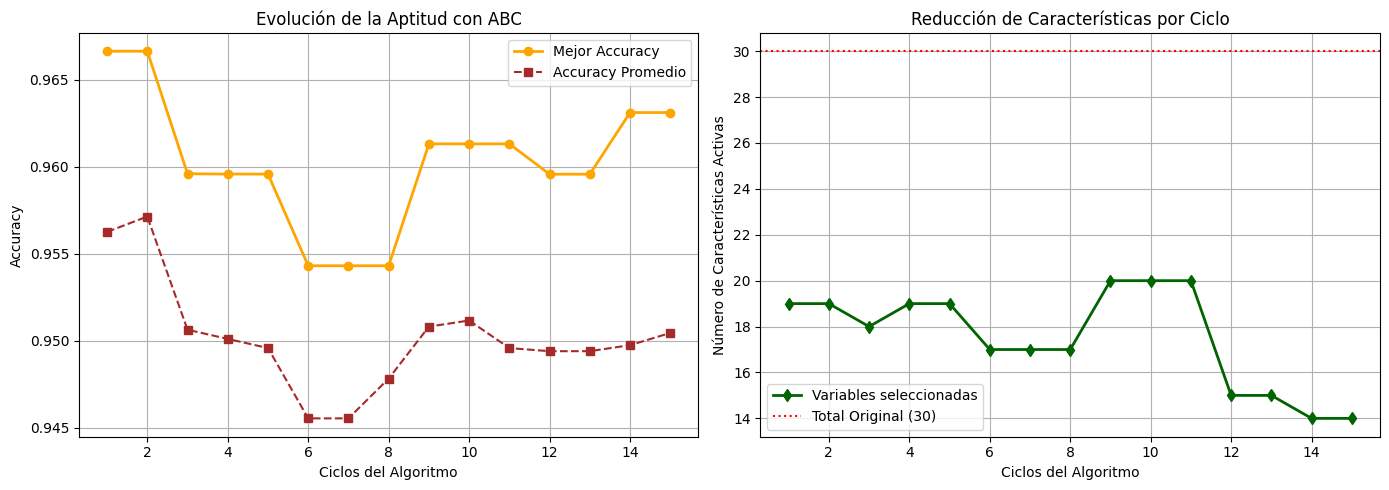

In [ ]:
# ==============================================================================
# CELDA 5: VISUALIZACIÓN GRÁFICA DEL RENDIMIENTO ABC
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Evolución del Accuracy
ax1.plot(range(1, CICLOS_MAXIMOS + 1), historial_mejor_accuracy, marker='o', color='orange', linewidth=2, label='Mejor Accuracy')
ax1.plot(range(1, CICLOS_MAXIMOS + 1), historial_accuracy_promedio, marker='s', linestyle='--', color='brown', label='Accuracy Promedio')
ax1.set_title("Evolución de la Aptitud con ABC")
ax1.set_xlabel("Ciclos del Algoritmo")
ax1.set_ylabel("Accuracy")
ax1.grid(True)
ax1.legend()

# Gráfico 2: Reducción de Características
ax2.plot(range(1, CICLOS_MAXIMOS + 1), historial_caracteristicas, marker='d', color='darkgreen', linewidth=2, label='Variables seleccionadas')
ax2.axhline(y=n_caracteristicas, color='red', linestyle=':', label='Total Original (30)')
ax2.set_title("Reducción de Características por Ciclo")
ax2.set_xlabel("Ciclos del Algoritmo")
ax2.set_ylabel("Número de Características Activas")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# CELDA 6: RESULTADOS Y COMPARATIVA FINAL EN ESPAÑOL
# ==============================================================================
mascara_ganadora = mejor_solucion_global > 0.5
columnas_seleccionadas = X.columns[mascara_ganadora].tolist()

# Evaluación con TODAS las características
clasificador_completo = RandomForestClassifier(n_estimators=20, random_state=42)
accuracy_completo = cross_val_score(clasificador_completo, X, y, cv=3, scoring='accuracy').mean()

print("============================================================")
print("             RESULTADO FINAL DEL ALGORITMO ABC              ")
print("============================================================")
print(f"Accuracy con TODAS las 30 características: {accuracy_completo * 100:.2f}%")
print(f"Accuracy con SELECCIÓN ABC ({len(columnas_seleccionadas)} caract.): {mejor_accuracy_global * 100:.2f}%")
print(f"Reducción total de dimensiones: {((30 - len(columnas_seleccionadas)) / 30) * 100:.1f}%")

print("\nLista de características seleccionadas en español:")
for i, col in enumerate(columnas_seleccionadas, 1):
    print(f"  {i:02d}. {col}")
print("============================================================")

             RESULTADO FINAL DEL ALGORITMO ABC              
Accuracy con TODAS las 30 características: 95.43%
Accuracy con SELECCIÓN ABC (19 caract.): 96.66%
Reducción total de dimensiones: 36.7%

Lista de características seleccionadas en español:
  01. Radio promedio
  02. Textura promedio
  03. Perímetro promedio
  04. Compacidad promedio
  05. Puntos cóncavos promedio
  06. Simetría promedio
  07. Dimensión fractal promedio
  08. Perímetro SE
  09. Compacidad SE
  10. Concavidad SE
  11. Puntos cóncavos SE
  12. Simetría SE
  13. Peor radio
  14. Peor textura
  15. Peor área
  16. Peor suavidad
  17. Peor compacidad
  18. Peor concavidad
  19. Peor puntos cóncavos
